# DrawNet — Colab Training

End-to-end pipeline: data download → annotation → caching → splitting → training.

**Before running:**
1. Runtime → Change runtime type → T4 GPU
2. Upload your Kaggle token when prompted in the credentials cell
3. Upload the project zip to Drive OR let the notebook clone from GitHub

## 1. Mount Google Drive (for persistent storage)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/DrawNet'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project will persist at: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Project will persist at: /content/drive/MyDrive/DrawNet


## 2. Install dependencies

In [2]:
!pip install -q kaggle scikit-learn tqdm pyyaml pandas pillow matplotlib
import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT AVAILABLE — check Runtime type!"}')

PyTorch: 2.10.0+cu128
GPU: Tesla T4


## 3. Set up project

Upload your project as a zip to Drive OR clone from GitHub.

In [3]:
import os, shutil

PROJECT_ZIP = f'{DRIVE_DIR}/drawnet.zip'   # <-- upload drawnet.zip to Drive/DrawNet/
WORK_DIR    = '/content/drawnet'

if os.path.exists(PROJECT_ZIP):
    if os.path.exists(WORK_DIR):
        shutil.rmtree(WORK_DIR)
    !unzip -q "{PROJECT_ZIP}" -d /content/
    print(f'Extracted to {WORK_DIR}')
else:
    # Option B: clone from GitHub
    GITHUB_REPO = 'kaul01/drawnet'   # <-- change this
    !git clone https://github.com/{GITHUB_REPO} {WORK_DIR}

os.chdir(WORK_DIR)
print(f'Working directory: {os.getcwd()}')
!ls

Extracted to /content/drawnet
Working directory: /content/drawnet
configs  CONTEXT.md  HANDOVER.md  notebooks  README.md	requirements.txt  src


## 4. Kaggle credentials

In [13]:
import os, json

KAGGLE_USERNAME = 'saka2453'   # <-- fill in
KAGGLE_KEY      = '76acc1a5eef0c6d27ca3edf7ed8d94b0'    # <-- fill in

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_json = os.path.expanduser('~/.kaggle/kaggle.json')
with open(kaggle_json, 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(kaggle_json, 0o600)
print('Kaggle credentials written.')

Kaggle credentials written.


## 5. Download datasets (QuickDraw & TU-Berlin)

In [16]:
# ── QuickDraw .npy files (gsutil method) ──────────────────────────────────────
import os
import shutil

QD_RAW = 'data/raw/quickdraw'
os.makedirs(QD_RAW, exist_ok=True)

CATEGORIES = [
    'face', 'house', 'tree', 'cat', 'car',
    'bird', 'dog', 'fish', 'flower', 'bicycle'
]

# Check Drive cache first
QD_DRIVE = f'{DRIVE_DIR}/data/raw/quickdraw'
if os.path.exists(QD_DRIVE) and len(os.listdir(QD_DRIVE)) >= 10:
    print('QuickDraw found in Drive — copying...')
    shutil.copytree(QD_DRIVE, QD_RAW, dirs_exist_ok=True)
else:
    print('Downloading QuickDraw from Google Cloud Storage via gsutil...')

    # Download JUST the 10 categories we need in parallel
    !gsutil -m cp \
      "gs://quickdraw_dataset/full/numpy_bitmap/face.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/house.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/tree.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/cat.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/car.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/bird.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/dog.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/fish.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/flower.npy" \
      "gs://quickdraw_dataset/full/numpy_bitmap/bicycle.npy" \
      {QD_RAW}/

    os.makedirs(QD_DRIVE, exist_ok=True)
    shutil.copytree(QD_RAW, QD_DRIVE, dirs_exist_ok=True)
    print('Saved QuickDraw to Drive.')

print('QuickDraw files:', len(os.listdir(QD_RAW)))


Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/face.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/house.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/tree.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/cat.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/car.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/bird.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/dog.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/fish.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/flower.npy...
Copying gs://quickdraw_dataset/full/numpy_bitmap/bicycle.npy...
\ [10/10 files][  1.0 GiB/  1.0 GiB] 100% Done  90.3 MiB/s ETA 00:00:00         
Operation completed over 10 objects/1.0 GiB.   

In [17]:
# ── TU-Berlin dataset ──────────────────────────────────────
TUB_RAW = 'data/raw/tuberlin'
TUB_DRIVE = f'{DRIVE_DIR}/data/raw/tuberlin'

if os.path.exists(TUB_DRIVE) and len(os.listdir(TUB_DRIVE)) >= 20:
    print('TU-Berlin found in Drive — copying...')
    shutil.copytree(TUB_DRIVE, TUB_RAW, dirs_exist_ok=True)
else:
    print('Downloading TU-Berlin via src/download_tuberlin.py...')
    !python src/download_tuberlin.py --extract
    print('Copying to Drive...')
    os.makedirs(TUB_DRIVE, exist_ok=True)
    shutil.copytree(TUB_RAW, TUB_DRIVE, dirs_exist_ok=True)
    print('Saved TU-Berlin to Drive.')
print('TU-Berlin folders:', len(os.listdir(TUB_RAW)))

Dataset URL: https://www.kaggle.com/datasets/zara2099/tu-berlin-hand-sketch-image-dataset
License(s): CC0-1.0
100% 3.72G/3.72G [00:50<00:00, 79.0MB/s]

Downloaded: data/raw/tuberlin/tu-berlin-hand-sketch-image-dataset.zip  (3999.3 MB)

Inspecting zip: data/raw/tuberlin/tu-berlin-hand-sketch-image-dataset.zip
Found 250 categories in zip.

Category match report:
  Wanted                     Zip key                    Status
  -------------------------  -------------------------  ------
  airplane                   airplane                   OK
  butterfly                  butterfly                  OK
  elephant                   elephant                   OK
  horse                      horse                      OK
  rabbit                     rabbit                     OK
  bear (animal)              bear (animal)              OK
  mushroom                   mushroom                   OK
  cup                        cup                        OK
  umbrella                   umbrella  

## 6. Pipeline Step 1 — Build Annotations

Scans raw data, assigns intent labels, flags 20% for deviations.

In [18]:
!python src/build_annotations.py --show_stats

Scanning QuickDraw ...
  [QuickDraw] face                : 5000 samples  (label 0)
  [QuickDraw] house               : 5000 samples  (label 1)
  [QuickDraw] tree                : 5000 samples  (label 2)
  [QuickDraw] cat                 : 5000 samples  (label 3)
  [QuickDraw] car                 : 5000 samples  (label 4)
  [QuickDraw] bird                : 5000 samples  (label 5)
  [QuickDraw] dog                 : 5000 samples  (label 6)
  [QuickDraw] fish                : 5000 samples  (label 7)
  [QuickDraw] flower              : 5000 samples  (label 8)
  [QuickDraw] bicycle             : 5000 samples  (label 9)

Scanning TU-Berlin ...
  [TU-Berlin] airplane            : 434 samples  (label 10)
  [TU-Berlin] butterfly           : 283 samples  (label 11)
  [TU-Berlin] elephant            : 357 samples  (label 12)
  [TU-Berlin] horse               : 584 samples  (label 13)
  [TU-Berlin] rabbit              : 433 samples  (label 14)
  [TU-Berlin] bear_(animal)       : 418 samples  (lab

## 7. Pipeline Step 2 — Cache Dataset

Applies deviations and caches ~64k PNG files.

In [19]:
CACHE_DRIVE = f'{DRIVE_DIR}/data/augmented'
CACHE_LOCAL = 'data/augmented'

if os.path.exists(f'{CACHE_DRIVE}/index.csv'):
    print('Cache found in Drive — symlinking...')
    if not os.path.exists(CACHE_LOCAL):
        os.symlink(CACHE_DRIVE, CACHE_LOCAL)
    import pandas as pd
    print(f'Cache has {len(pd.read_csv(CACHE_LOCAL + "/index.csv"))} images in index.csv.')
else:
    print('Building cache (one-time ~10-15 min)...')
    !python src/cache_dataset.py

    print('Copying cache to Drive (this may take a few minutes)...')
    import shutil
    shutil.copytree(CACHE_LOCAL, CACHE_DRIVE)
    print('Cache saved to Drive.')

Building cache (one-time ~10-15 min)...

Processing 64158 images -> data/augmented ...
100% 64158/64158 [38:37<00:00, 27.68img/s]

Done. 64158 images saved to data/augmented
Disk usage estimate: 1253 MB

--- Deviation distribution ---
  rotation                      :   7826  (12.2%)
  closure_failure               :   7684  (12.0%)
  spatial_disorganization       :   7821  (12.2%)
  size_distortion               :   7829  (12.2%)
  Any deviation                 :  12833  (20.0%)

--- Intent class distribution ---
   0  face                :  5000
   1  house               :  5000
   2  tree                :  5000
   3  cat                 :  5000
   4  car                 :  5000
   5  bird                :  5000
   6  dog                 :  5000
   7  fish                :  5000
   8  flower              :  5000
   9  bicycle             :  5000
  10  airplane            :   434
  11  butterfly           :   283
  12  elephant            :   357
  13  horse               :   584
  14

## 8. Pipeline Step 3 — Split Dataset

Performs 80/20 stratified split.

In [20]:
!python src/split_dataset.py --show_stats

import shutil
# Sync split files to Drive so we don't lose them
if os.path.exists('data/augmented/train.csv'):
    shutil.copy('data/augmented/train.csv', f'{DRIVE_DIR}/data/augmented/train.csv')
    shutil.copy('data/augmented/test.csv', f'{DRIVE_DIR}/data/augmented/test.csv')

Loaded 64158 rows from data/augmented/index.csv
Saved train.csv: 51326 rows  -> data/augmented/train.csv
Saved test.csv : 12832 rows  -> data/augmented/test.csv

SPLIT STATISTICS  (total: 64158)

Train (51326 samples):
  Clean   :  41088  (80.1%)
  Deviated:  10238  (19.9%)
  Deviation rates:
    rotation                      :  6275  (12.2%)
    closure_failure               :  6139  (12.0%)
    spatial_disorganization       :  6241  (12.2%)
    size_distortion               :  6196  (12.1%)
  Samples per intent class:
     0  face                : 4000
     1  house               : 4000
     2  tree                : 4000
     3  cat                 : 4000
     4  car                 : 4000
     5  bird                : 4000
     6  dog                 : 4000
     7  fish                : 4000
     8  flower              : 4000
     9  bicycle             : 4000
    10  airplane            : 347
    11  butterfly           : 227
    12  elephant            : 286
    13  horse         

## 9. Pipeline Step 4 — Train DrawNet

In [21]:
CKPT_DRIVE = f'{DRIVE_DIR}/outputs/checkpoints'
CKPT_LOCAL = 'outputs/checkpoints'
os.makedirs(CKPT_LOCAL, exist_ok=True)

import shutil
resume_flag = ''
if os.path.exists(f'{CKPT_DRIVE}/best.pt'):
    shutil.copy(f'{CKPT_DRIVE}/best.pt', f'{CKPT_LOCAL}/best.pt')
    epoch_ckpts = sorted([
        f for f in os.listdir(CKPT_DRIVE) if f.startswith('epoch_')
    ])
    if epoch_ckpts:
        latest = epoch_ckpts[-1]
        shutil.copy(f'{CKPT_DRIVE}/{latest}', f'{CKPT_LOCAL}/{latest}')
        resume_flag = f'--resume {CKPT_LOCAL}/{latest}'
        print(f'Resuming from {latest}')
    else:
        resume_flag = f'--resume {CKPT_LOCAL}/best.pt'
        print('Resuming from best.pt')
else:
    print('No checkpoint found — training from scratch.')

print(f'Resume flag: {resume_flag or "(none)"}')

No checkpoint found — training from scratch.
Resume flag: (none)


In [22]:
!python -u src/train.py \
    --config configs/config_colab.yaml \
    {resume_flag}

Device: cuda

Building dataloaders ...
[CachedDataset] Loaded 51326 samples from data/augmented/train.csv
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
[CachedDataset] Loaded 12832 samples from data/augmented/test.csv
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow 

## 10. Back up checkpoints + logs to Drive

In [ ]:
import shutil

for folder in ['outputs/checkpoints', 'outputs/logs', 'outputs/results']:
    src = f'/content/drawnet/{folder}'
    dst = f'{DRIVE_DIR}/{folder}'
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f'Backed up {folder}')

print('Done. Checkpoints and logs saved to Drive.')

## 11. Quick evaluation — view training curves

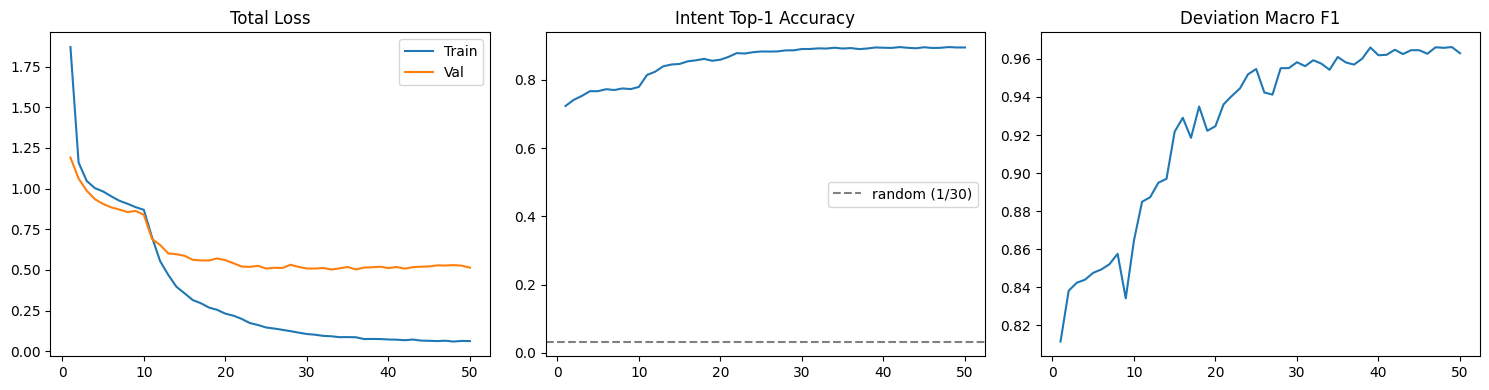

 epoch  val_loss  intent_top1_acc  dev_macro_f1
    41  0.517677         0.893629      0.962183
    42  0.507948         0.896065      0.964832
    43  0.517024         0.894019      0.962574
    44  0.519610         0.892558      0.964606
    45  0.521124         0.895675      0.964584
    46  0.528006         0.893435      0.962713
    47  0.527001         0.893922      0.966134
    48  0.529535         0.896162      0.965841
    49  0.526140         0.894896      0.966249
    50  0.513711         0.894993      0.962986


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_path = 'outputs/logs/train_log.csv'
if os.path.exists(log_path):
    log = pd.read_csv(log_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(log['epoch'], log['train_loss'], label='Train')
    axes[0].plot(log['epoch'], log['val_loss'],   label='Val')
    axes[0].set_title('Total Loss'); axes[0].legend()

    axes[1].plot(log['epoch'], log['intent_top1_acc'])
    axes[1].set_title('Intent Top-1 Accuracy')
    axes[1].axhline(0.033, color='gray', linestyle='--', label='random (1/30)')
    axes[1].legend()

    axes[2].plot(log['epoch'], log['dev_macro_f1'])
    axes[2].set_title('Deviation Macro F1')

    plt.tight_layout()
    os.makedirs('outputs/results', exist_ok=True)
    plt.savefig('outputs/results/training_curves.png', dpi=150)
    plt.show()
    print(log[['epoch','val_loss','intent_top1_acc','dev_macro_f1']].tail(10).to_string(index=False))
else:
    print("No training log found. Did training complete?")